Diabetes Prediction - Logistic Regression from scratch

In [1]:
#importing the dependencies
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

Workflow:
1. set learning rate and no.of iterations, initiate random weights and bias values
2. build logistic regression function(sigmoid function)
3. update parameters using gradient descent, best model with minimum cost function is obtained
4. build predict function to determine the class of data point

In [2]:
class Logistic_Regression():
    #reference of the instance we are creating = self
    #declaring or initiating the learning rate and no.of iterations
    def __init__(self,learning_rate,no_of_iterations):
        self.learning_rate=learning_rate
        self.no_of_iterations=no_of_iterations
    #fit function to train the model with dataset
    def fit(self,x,y):
        #no.of data points=no.of rows --> m
        #no.of input features=no.of columns --> n
        self.m,self.n=x.shape
        #initiating weights and bias
        self.w=np.zeros(self.n)  #creates 1d array with shape (n,)
        self.b=0
        self.x=x
        self.y=y
        #impleting gradient descent algorithm for optimisation
        for i in range(self.no_of_iterations):
            self.update_weights()
    def update_weights(self):
        #y_hat formula(sigmoid function)
        # dot product of 2d array of shape=(m,n) and 1d array with shape=(n,), resulting array shape=(m,) -->1d array
        y_hat=1/(1+np.exp(-(self.x.dot(self.w)+self.b)))    #z=wx+b
        #built the derivates or gradient
        dw=(1/self.m)*np.dot(self.x.T,(y_hat-self.y))
        db=(1/self.m)*np.sum(y_hat-self.y)
        self.w-=self.learning_rate*dw
        self.b-=self.learning_rate*db
    #sigmoid equation and decision boundary
    def predict(self,x):
        y_pred=1/(1+np.exp(-(x.dot(self.w)+self.b)))
        y_pred=np.where(y_pred>0.5,1,0)
        return y_pred


Loading the dataset into a pandas dataframe

In [3]:
diabetes_dataset=pd.read_csv("diabetes.csv")

Data_preprocessing:

In [4]:
diabetes_dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
diabetes_dataset.shape

(768, 9)

In [6]:
diabetes_dataset.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
diabetes_dataset.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [8]:
diabetes_dataset['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

0=non_diabetic

1=diabetic

In [9]:
diabetes_dataset.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


In [10]:
#separating features and targets
features=diabetes_dataset.drop(columns='Outcome')
target=diabetes_dataset['Outcome']

In [11]:
print(features)

     Pregnancies  Glucose  BloodPressure  ...   BMI  DiabetesPedigreeFunction  Age
0              6      148             72  ...  33.6                     0.627   50
1              1       85             66  ...  26.6                     0.351   31
2              8      183             64  ...  23.3                     0.672   32
3              1       89             66  ...  28.1                     0.167   21
4              0      137             40  ...  43.1                     2.288   33
..           ...      ...            ...  ...   ...                       ...  ...
763           10      101             76  ...  32.9                     0.171   63
764            2      122             70  ...  36.8                     0.340   27
765            5      121             72  ...  26.2                     0.245   30
766            1      126             60  ...  30.1                     0.349   47
767            1       93             70  ...  30.4                     0.315   23

[76

In [12]:
print(target)

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64


Data_splitting into training and testing data

In [13]:
x_train,x_test,y_train,y_test=train_test_split(features,target,test_size=0.2,random_state=0)

Data-Standardisation

In [14]:
scaler=StandardScaler()
scaler.fit(x_train)


,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [15]:
x_train_scaled=scaler.transform(x_train)

In [16]:
print(x_train_scaled)

[[ 0.90832902  0.91569367  0.44912368 ...  0.37852648  0.67740401
   1.69955804]
 [ 0.03644676 -0.75182191 -0.47230103 ... -0.50667229 -0.07049698
  -0.96569189]
 [-1.12606292  1.38763205  1.06340683 ...  2.54094063 -0.11855487
  -0.88240283]
 ...
 [ 0.03644676 -0.84620959 -0.21634972 ... -0.94927168 -0.95656442
  -1.04898095]
 [ 2.0708387  -1.12937261  0.24436264 ... -0.26640405 -0.50001442
   0.11706589]
 [ 0.32707418  0.47521786  0.65388473 ... -4.07275877  0.52121586
   2.94889395]]


In [17]:
x_test_scaled=scaler.transform(x_test)

In [18]:
print(x_train_scaled.std())

1.0


In [19]:
print(x_test_scaled.std())

0.9479913075305091


Training the model

In [20]:
classifier=Logistic_Regression(learning_rate=0.02,no_of_iterations=5000)

In [21]:
classifier.fit(x_train_scaled,y_train)   #training the model with x_train_scaled and y_train values

Model Evaluation

Accuracy Score

In [22]:
#accuracy score for training data
y_train_prediction=classifier.predict(x_train_scaled)
training_data_accuracy=accuracy_score(y_train,y_train_prediction)
print("Accuracy score of the train data: ",training_data_accuracy)

Accuracy score of the train data:  0.762214983713355


In [23]:
#accuracy score for testing data
y_test_prediction=classifier.predict(x_test_scaled)
test_data_accuracy=accuracy_score(y_test,y_test_prediction)
print("Accuracy score for test data: ", test_data_accuracy)

Accuracy score for test data:  0.8246753246753247


Making a Predictive System:

In [24]:

# REMOVED SPACES to exactly match the dataset columns:
feature_names = ["Pregnancies", "Glucose", "Blood Pressure", "Skin Thickness", "Insulin", "BMI", "Diabetes Pedigree Function", "Age"]
user_input = []
print("Enter the Patient Clinical Details: ")
#getting input from user
#Eg:(2,138,72,35,0,33.6,0.627,47)
for feature in feature_names:
    val = float(input(f"{feature}: "))
    user_input.append(val)

# converting into numpy array
np_user_input = np.asarray(user_input)

# reshape array for a single instance prediction
np_user_input_reshaped = np_user_input.reshape(1, -1)

# scaling the input data
std_data = scaler.transform(np_user_input_reshaped)

# predicting using classifier
prediction = classifier.predict(std_data)

# displaying the output
print("\n---Diagnostic Result---")
if prediction[0] == 0:
    print('The person is not diabetic.')
else:
    print("The person is diabetic.")


Enter the Patient Clinical Details: 

---Diagnostic Result---
The person is diabetic.


c:\code\python\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Confusion Matrix

In [25]:
cm=confusion_matrix(y_test,y_test_prediction)
print(cm)

[[98  9]
 [18 29]]


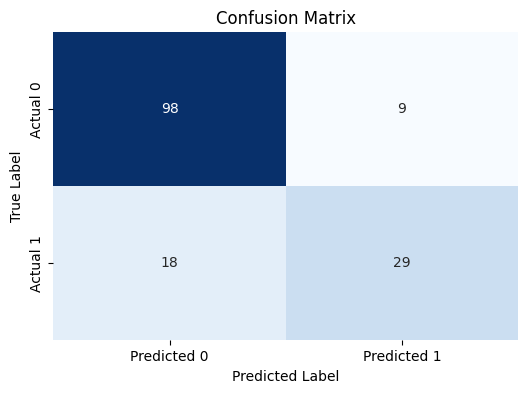

In [26]:
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',cbar=False,
            xticklabels=['Predicted 0','Predicted 1'],
            yticklabels=['Actual 0','Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.savefig("Confusion_matrix.png",dpi=300,bbox_inches='tight')
plt.show()

Model Evaluation Metrics

In [27]:
precision=precision_score(y_test,y_test_prediction)
recall=recall_score(y_test,y_test_prediction)
f1=f1_score(y_test,y_test_prediction)
print(f"Precision: {precision:.4f}")
print(f"Recall Score: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Precision: 0.7632
Recall Score: 0.6170
F1 Score: 0.6824


Cross Validation

In [29]:
#using sklearn's logistic regression for cross validation
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
pipeline=Pipeline([('scalar',StandardScaler()),('model',LogisticRegression(max_iter=1000))])
cv_scores=cross_val_score(pipeline,features,target,cv=5,scoring='accuracy')
print("Cross Validation SCores: ", cv_scores)
print("Mean Accuracy: ",cv_scores.mean().round(4))  
print("Standard Deviation: ",cv_scores.std().round(4))

Cross Validation SCores:  [0.77272727 0.74675325 0.75324675 0.81699346 0.76470588]
Mean Accuracy:  0.7709
Standard Deviation:  0.0247
